# 07 — Teacher Hidden Representations & Real Conversion

**Goal**: Extract and analyze hidden representations from the real tiny-aya-global teacher, then perform actual block conversion with real weights.

This is the critical bridge between synthetic validation (NB06) and real distillation (Stage 2).

**Experiments**:
1. Layer-wise representation analysis (CKA self-similarity heatmap)
2. Multilingual representation similarity (do languages cluster?)
3. Real attention→SSM conversion with CKA measurement
4. Real FFN→MoE conversion with CKA measurement
5. Layer mapping quality assessment

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parent.parent / "aetheris"))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import json
import time

from transformers import AutoModelForCausalLM, AutoTokenizer
from aya_distill.distill.cka import linear_cka
from aya_distill.distill.hooks import ActivationStore, register_teacher_hooks
from aya_distill.distill.converter import (
    ConversionConfig, convert_attention_to_ssm, convert_ffn_to_moe, svd_project
)
from aya_distill.languages import LANGUAGES
from aya_distill.testing.fixtures import MULTILINGUAL_PROMPTS
from aetheris import AetherisConfig
from aetheris.modules.ssm import SSMBlock
from aetheris.modules.moe import SparseMoELayer

torch.manual_seed(42)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.10.0+cu128
CUDA: True


## 1. Load Teacher Model

In [2]:
MODEL_NAME = "CohereLabs/tiny-aya-global"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

t0 = time.perf_counter()
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="cpu",
    trust_remote_code=True,
)
model.eval()
load_time = time.perf_counter() - t0

cfg = model.config
n_layers = cfg.num_hidden_layers
hidden = cfg.hidden_size
teacher_layers = list(model.model.layers)

print(f"Loaded in {load_time:.1f}s")
print(f"Architecture: {n_layers} layers, hidden={hidden}, intermediate={cfg.intermediate_size}")
print(f"GQA: {cfg.num_attention_heads} heads, {cfg.num_key_value_heads} KV heads")
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e9:.2f}B")
if torch.cuda.is_available():
    print(f"GPU mem: {torch.cuda.memory_allocated()/1024**3:.2f}GB")
else:
    print("Running on CPU")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded in 27.9s
Architecture: 36 layers, hidden=2048, intermediate=11008
GQA: 16 heads, 4 KV heads
Parameters: 3.35B
GPU mem: 0.00GB


## 2. Layer Self-Similarity (CKA Heatmap)

Compute CKA between every pair of teacher layers to understand the representation structure. This reveals which layers are redundant (high CKA) and where major representation shifts happen.

In [3]:
# Extract activations from sampled layers using hooks
store = ActivationStore(detach=True, device="cpu")

# Sample every 3rd layer for memory efficiency (36 layers -> 12 samples)
sample_layers = list(range(0, n_layers, 3))
register_teacher_hooks(model, store, layer_indices=sample_layers, hook_attention=True, hook_ffn=False)

# Use a diverse set of prompts
prompts = MULTILINGUAL_PROMPTS["general_knowledge"]
test_langs = ["en", "es", "ar", "hi", "zh", "ja", "sw", "tr", "ru", "th"]
test_texts = [prompts[l] for l in test_langs if l in prompts]

print(f"Extracting activations from {len(sample_layers)} layers across {len(test_texts)} languages...")

with torch.no_grad():
    for text in test_texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(model.device)
        _ = model(**inputs)

activations = store.collect()
store.remove_hooks()

print(f"Collected {len(activations)} layer activations")
for name, act in activations.items():
    print(f"  {name}: {act.shape}")

Extracting activations from 12 layers across 10 languages...


Collected 12 layer activations
  teacher.attn.0: torch.Size([166, 2048])
  teacher.attn.3: torch.Size([166, 2048])
  teacher.attn.6: torch.Size([166, 2048])
  teacher.attn.9: torch.Size([166, 2048])
  teacher.attn.12: torch.Size([166, 2048])
  teacher.attn.15: torch.Size([166, 2048])
  teacher.attn.18: torch.Size([166, 2048])
  teacher.attn.21: torch.Size([166, 2048])
  teacher.attn.24: torch.Size([166, 2048])
  teacher.attn.27: torch.Size([166, 2048])
  teacher.attn.30: torch.Size([166, 2048])
  teacher.attn.33: torch.Size([166, 2048])


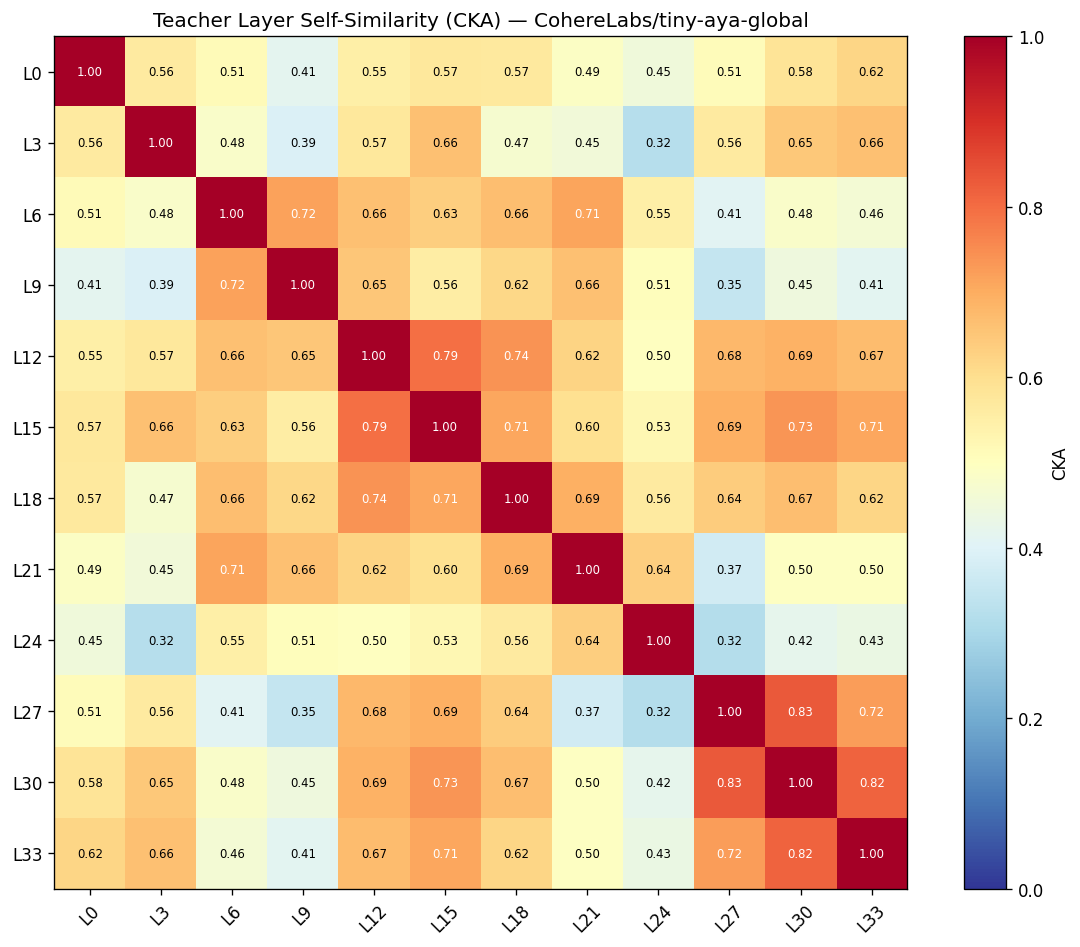


Layer similarity insights:
  L0 → L3: CKA=0.563 [transition]
  L3 → L6: CKA=0.483 [transition]
  L6 → L9: CKA=0.719 [moderate]
  L9 → L12: CKA=0.650 [transition]
  L12 → L15: CKA=0.794 [moderate]
  L15 → L18: CKA=0.708 [moderate]
  L18 → L21: CKA=0.693 [transition]
  L21 → L24: CKA=0.636 [transition]
  L24 → L27: CKA=0.319 [transition]
  L27 → L30: CKA=0.831 [moderate]
  L30 → L33: CKA=0.816 [moderate]


In [4]:
# Compute CKA heatmap between all sampled layer pairs
layer_names = sorted(activations.keys(), key=lambda x: int(x.split('.')[-1]))
n = len(layer_names)
cka_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        # Subsample tokens for CKA (memory efficient)
        a_i = activations[layer_names[i]][:500]
        a_j = activations[layer_names[j]][:500]
        cka_val = linear_cka(a_i, a_j).item()
        cka_matrix[i, j] = cka_val
        cka_matrix[j, i] = cka_val

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cka_matrix, cmap="RdYlBu_r", vmin=0, vmax=1)
layer_labels = [f"L{x.split('.')[-1]}" for x in layer_names]
ax.set_xticks(range(n))
ax.set_xticklabels(layer_labels, rotation=45)
ax.set_yticks(range(n))
ax.set_yticklabels(layer_labels)
ax.set_title(f"Teacher Layer Self-Similarity (CKA) — {MODEL_NAME}")
plt.colorbar(im, ax=ax, label="CKA")

# Annotate values
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{cka_matrix[i,j]:.2f}", ha="center", va="center", fontsize=7,
               color="white" if cka_matrix[i,j] > 0.7 else "black")

plt.tight_layout()
Path("../results").mkdir(exist_ok=True)
plt.savefig("../results/teacher_layer_cka_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Find layer groups (high internal CKA)
print("\nLayer similarity insights:")
for i in range(n-1):
    adj_cka = cka_matrix[i, i+1]
    status = "similar" if adj_cka > 0.9 else "transition" if adj_cka < 0.7 else "moderate"
    print(f"  {layer_labels[i]} → {layer_labels[i+1]}: CKA={adj_cka:.3f} [{status}]")

## 3. Multilingual Representation Similarity

Do languages cluster in the teacher's hidden space? This determines whether distillation can preserve cross-lingual transfer.

Extracting layer 18 representations for 30 languages...


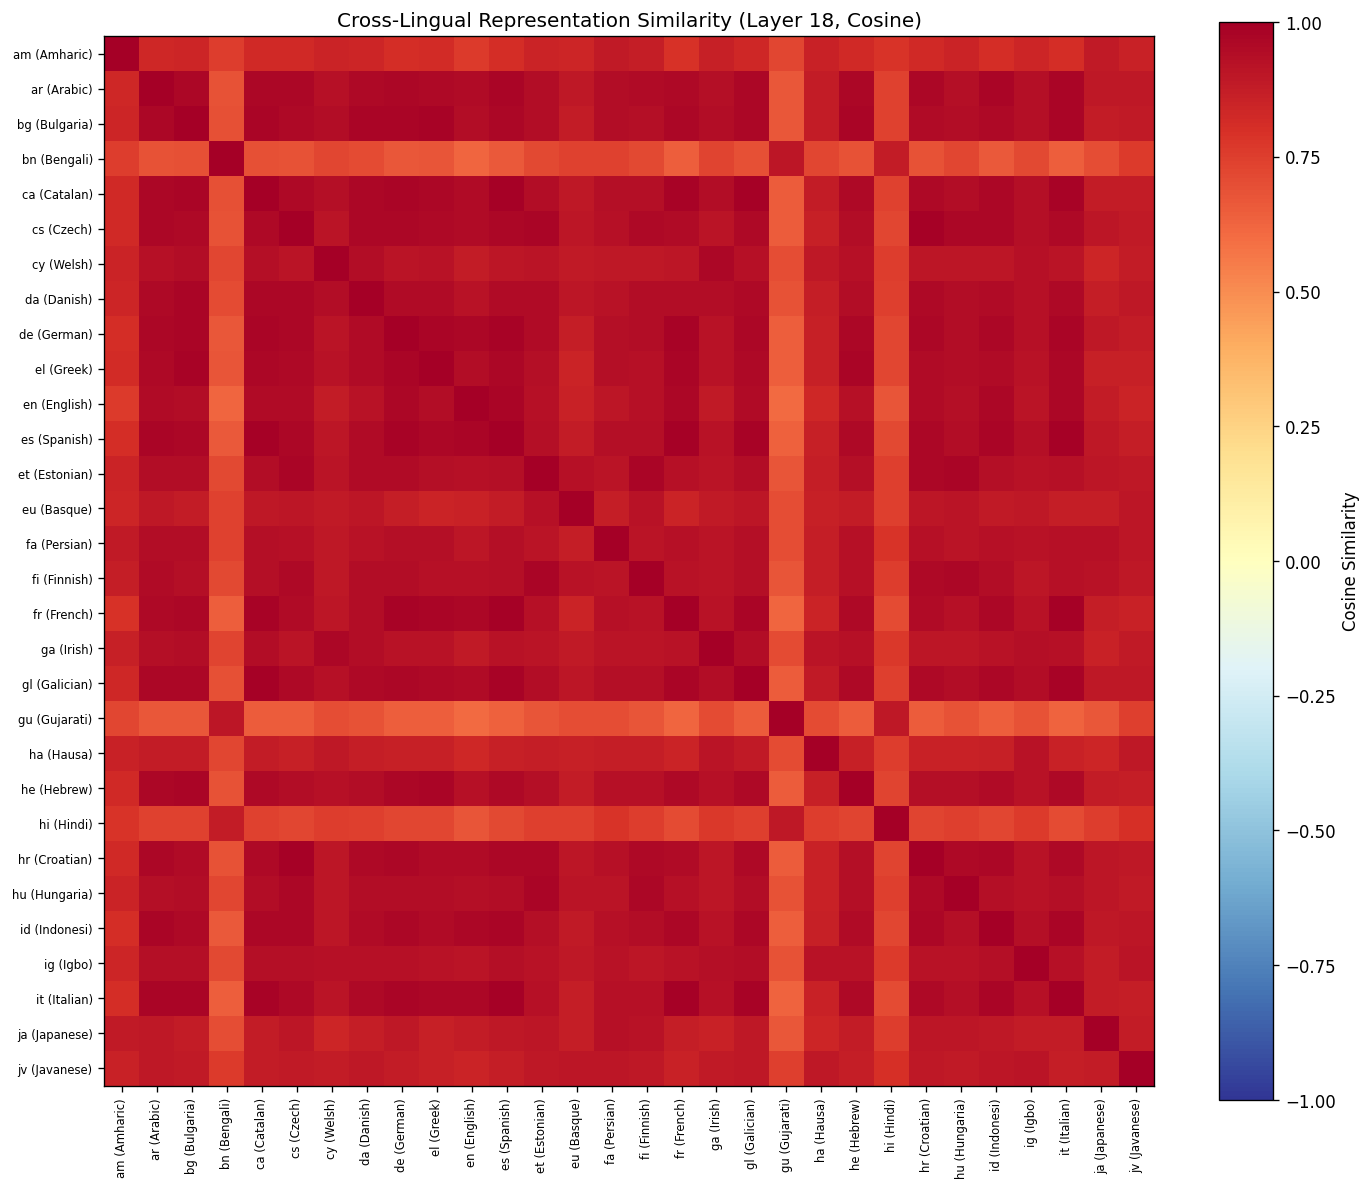


Most similar language pairs (layer representation):
  ca-gl (Catalan-Galician): 0.9913 [SAME family]
  es-it (Spanish-Italian): 0.9906 [SAME family]
  cs-hr (Czech-Croatian): 0.9889 [SAME family]
  es-fr (Spanish-French): 0.9866 [SAME family]
  ca-es (Catalan-Spanish): 0.9863 [SAME family]
  fr-it (French-Italian): 0.9845 [SAME family]
  es-gl (Spanish-Galician): 0.9839 [SAME family]
  ca-it (Catalan-Italian): 0.9819 [SAME family]
  bg-el (Bulgarian-Greek): 0.9804 [SAME family]
  de-es (German-Spanish): 0.9796 [SAME family]

Least similar:
  es-gu (Spanish-Gujarati): 0.6341
  gu-it (Gujarati-Italian): 0.6267
  fr-gu (French-Gujarati): 0.6247
  bn-en (Bengali-English): 0.6207
  en-gu (English-Gujarati): 0.6027


In [5]:
# Extract per-language representations from a middle layer
mid_layer = n_layers // 2
store2 = ActivationStore(detach=True, device="cpu")
register_teacher_hooks(model, store2, layer_indices=[mid_layer], hook_attention=True, hook_ffn=False)

lang_reps = {}  # lang_code -> mean hidden state
test_langs_full = [l for l in sorted(prompts.keys()) if l in LANGUAGES][:30]  # 30 languages

print(f"Extracting layer {mid_layer} representations for {len(test_langs_full)} languages...")

for lang in test_langs_full:
    store2.clear()
    text = prompts[lang]
    with torch.no_grad():
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(model.device)
        _ = model(**inputs)
    
    acts = store2.collect()
    key = list(acts.keys())[0]
    lang_reps[lang] = acts[key].mean(dim=0)  # Mean-pool over tokens

store2.remove_hooks()

# Compute pairwise cosine similarity
langs = sorted(lang_reps.keys())
n_langs = len(langs)
sim_matrix = np.zeros((n_langs, n_langs))

for i in range(n_langs):
    for j in range(n_langs):
        cos = torch.nn.functional.cosine_similarity(
            lang_reps[langs[i]].unsqueeze(0),
            lang_reps[langs[j]].unsqueeze(0),
        ).item()
        sim_matrix[i, j] = cos

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(sim_matrix, cmap="RdYlBu_r", vmin=-1, vmax=1)
lang_labels = [f"{l} ({LANGUAGES[l].name[:8]})" for l in langs]
ax.set_xticks(range(n_langs))
ax.set_xticklabels(lang_labels, rotation=90, fontsize=7)
ax.set_yticks(range(n_langs))
ax.set_yticklabels(lang_labels, fontsize=7)
ax.set_title(f"Cross-Lingual Representation Similarity (Layer {mid_layer}, Cosine)")
plt.colorbar(im, ax=ax, label="Cosine Similarity")
plt.tight_layout()
plt.savefig("../results/crosslingual_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

# Find highest/lowest similarity pairs
pairs = []
for i in range(n_langs):
    for j in range(i+1, n_langs):
        pairs.append((langs[i], langs[j], sim_matrix[i, j]))
pairs.sort(key=lambda x: x[2], reverse=True)

print("\nMost similar language pairs (layer representation):")
for l1, l2, sim in pairs[:10]:
    f1, f2 = LANGUAGES[l1].family, LANGUAGES[l2].family
    same = "SAME" if f1 == f2 else "DIFF"
    print(f"  {l1}-{l2} ({LANGUAGES[l1].name}-{LANGUAGES[l2].name}): {sim:.4f} [{same} family]")

print("\nLeast similar:")
for l1, l2, sim in pairs[-5:]:
    print(f"  {l1}-{l2} ({LANGUAGES[l1].name}-{LANGUAGES[l2].name}): {sim:.4f}")

## 4. Real Block Conversion — Attention → SSM

Convert actual teacher attention layers to student SSM blocks using the real weights. This is the ground truth for Stage 1.

In [6]:
# Student config matched to teacher
student_d_model = hidden // 2  # 1024
student_cfg = AetherisConfig(
    vocab_size=tokenizer.vocab_size,
    d_model=student_d_model,
    n_layer=24,
    num_experts=4,
    top_k=1,
    d_ff=cfg.intermediate_size // 4,
    ssm_d_state=16,
    ssm_expand=2,
    max_seq_len=128,
    gradient_checkpointing=False,
)

print(f"Student config: d_model={student_cfg.d_model}, d_inner={student_cfg.d_inner}, d_ff={student_cfg.d_ff}")

# Convert sampled teacher layers using activation-based CKA (no need to call individual layers)
conv_config = ConversionConfig(strategy="weight_map", a_init="exponential_decay")
conversion_layers = list(range(0, n_layers, n_layers // 8))[:8]  # 8 evenly spaced layers

conversion_results = []
print(f"\nConverting {len(conversion_layers)} teacher layers → SSM blocks...")

# Get teacher hidden states through full model pass for CKA comparison
test_text = "The theory of gravity explains how objects attract each other."
test_input = tokenizer(test_text, return_tensors="pt", truncation=True, max_length=32)

# Use hooks to get per-layer teacher outputs
cka_store = ActivationStore(detach=True, device="cpu")
register_teacher_hooks(model, cka_store, layer_indices=conversion_layers, hook_attention=True, hook_ffn=False)
with torch.no_grad():
    _ = model(**test_input)
teacher_acts = cka_store.collect()
cka_store.remove_hooks()

for t_idx in conversion_layers:
    attn = teacher_layers[t_idx].self_attn
    ssm = SSMBlock(student_cfg)
    
    # Convert weights
    metrics = convert_attention_to_ssm(attn, ssm, conv_config, layer_idx=t_idx)
    
    # Get teacher activation for this layer
    t_key = f"teacher.attn.{t_idx}"
    if t_key in teacher_acts:
        t_flat = teacher_acts[t_key][:, :student_d_model]  # project to student dim
        
        # Generate student output from same-dim input
        s_input = t_flat[:32].unsqueeze(0).float()  # (1, tokens, d_model)
        ssm.eval()
        ssm.float()
        s_out = ssm(s_input)
        s_flat = s_out.detach().reshape(-1, student_d_model)
        
        cka = linear_cka(t_flat[:32], s_flat).item()
    else:
        cka = float('nan')
    
    # Weight statistics
    v_weight = attn.v_proj.weight.data.float().cpu()
    in_proj = ssm.in_proj.weight.data[:ssm.d_inner].float().cpu()
    energy_ratio = torch.norm(in_proj).item() / (torch.norm(v_weight).item() + 1e-8)
    
    conversion_results.append({
        "teacher_layer": t_idx,
        "cka": round(cka, 4),
        "energy_ratio": round(energy_ratio, 4),
    })
    print(f"  Layer {t_idx:2d}: CKA={cka:.4f}, energy_ratio={energy_ratio:.4f}")

mean_cka = np.mean([r["cka"] for r in conversion_results if not np.isnan(r["cka"])])
print(f"\nMean CKA across layers: {mean_cka:.4f}")
print(f"Threshold: 0.75 — {'ABOVE' if mean_cka >= 0.75 else 'BELOW (refinement needed)'}")

Student config: d_model=1024, d_inner=2048, d_ff=2752

Converting 8 teacher layers → SSM blocks...


  Layer  0: CKA=0.5755, energy_ratio=0.7055


  Layer  4: CKA=0.6112, energy_ratio=0.7062


  Layer  8: CKA=0.7834, energy_ratio=0.7075


  Layer 12: CKA=0.6098, energy_ratio=0.7077


  Layer 16: CKA=0.3558, energy_ratio=0.7062


  Layer 20: CKA=0.7111, energy_ratio=0.7066


  Layer 24: CKA=0.8206, energy_ratio=0.7077


  Layer 28: CKA=0.3659, energy_ratio=0.7123

Mean CKA across layers: 0.6042
Threshold: 0.75 — BELOW (refinement needed)


## 5. Real FFN → MoE Conversion

In [7]:
# Convert FFN layers
moe_results = []
print(f"Converting {len(conversion_layers)} teacher MLP layers → MoE blocks...")

for strategy in ["replicate", "svd_split"]:
    print(f"\n  Strategy: {strategy}")
    for t_idx in conversion_layers[:4]:  # fewer for MoE (slower)
        mlp = teacher_layers[t_idx].mlp
        moe = SparseMoELayer(student_cfg)
        
        moe_config = ConversionConfig(strategy="weight_map", ffn_to_moe=strategy)
        metrics = convert_ffn_to_moe(mlp, moe, moe_config, layer_idx=t_idx)
        
        # Expert diversity: CKA between expert pairs
        expert_ckas = []
        for i in range(student_cfg.num_experts):
            for j in range(i+1, student_cfg.num_experts):
                w_i = moe.experts[i].w1.weight.data.float().cpu()
                w_j = moe.experts[j].w1.weight.data.float().cpu()
                cka = linear_cka(w_i, w_j).item()
                expert_ckas.append(cka)
        
        mean_expert_cka = np.mean(expert_ckas)
        moe_results.append({
            "teacher_layer": t_idx,
            "strategy": strategy,
            "mean_expert_cka": mean_expert_cka,
        })
        print(f"    Layer {t_idx:2d}: expert pairwise CKA={mean_expert_cka:.4f} "
              f"({'diverse' if mean_expert_cka < 0.5 else 'similar'})")

# Compare strategies
print("\nStrategy comparison:")
for strat in ["replicate", "svd_split"]:
    vals = [r["mean_expert_cka"] for r in moe_results if r["strategy"] == strat]
    print(f"  {strat:12s}: mean expert CKA = {np.mean(vals):.4f} "
          f"({'less diverse' if np.mean(vals) > 0.5 else 'more diverse'})")

Converting 8 teacher MLP layers → MoE blocks...

  Strategy: replicate


    Layer  0: expert pairwise CKA=0.8260 (similar)


    Layer  4: expert pairwise CKA=0.8870 (similar)


    Layer  8: expert pairwise CKA=0.8927 (similar)


    Layer 12: expert pairwise CKA=0.8913 (similar)

  Strategy: svd_split


    Layer  0: expert pairwise CKA=0.0962 (diverse)


    Layer  4: expert pairwise CKA=0.0954 (diverse)


    Layer  8: expert pairwise CKA=0.0972 (diverse)


    Layer 12: expert pairwise CKA=0.0970 (diverse)

Strategy comparison:
  replicate   : mean expert CKA = 0.8742 (less diverse)
  svd_split   : mean expert CKA = 0.0964 (more diverse)


## 6. Conversion Quality Across Depth

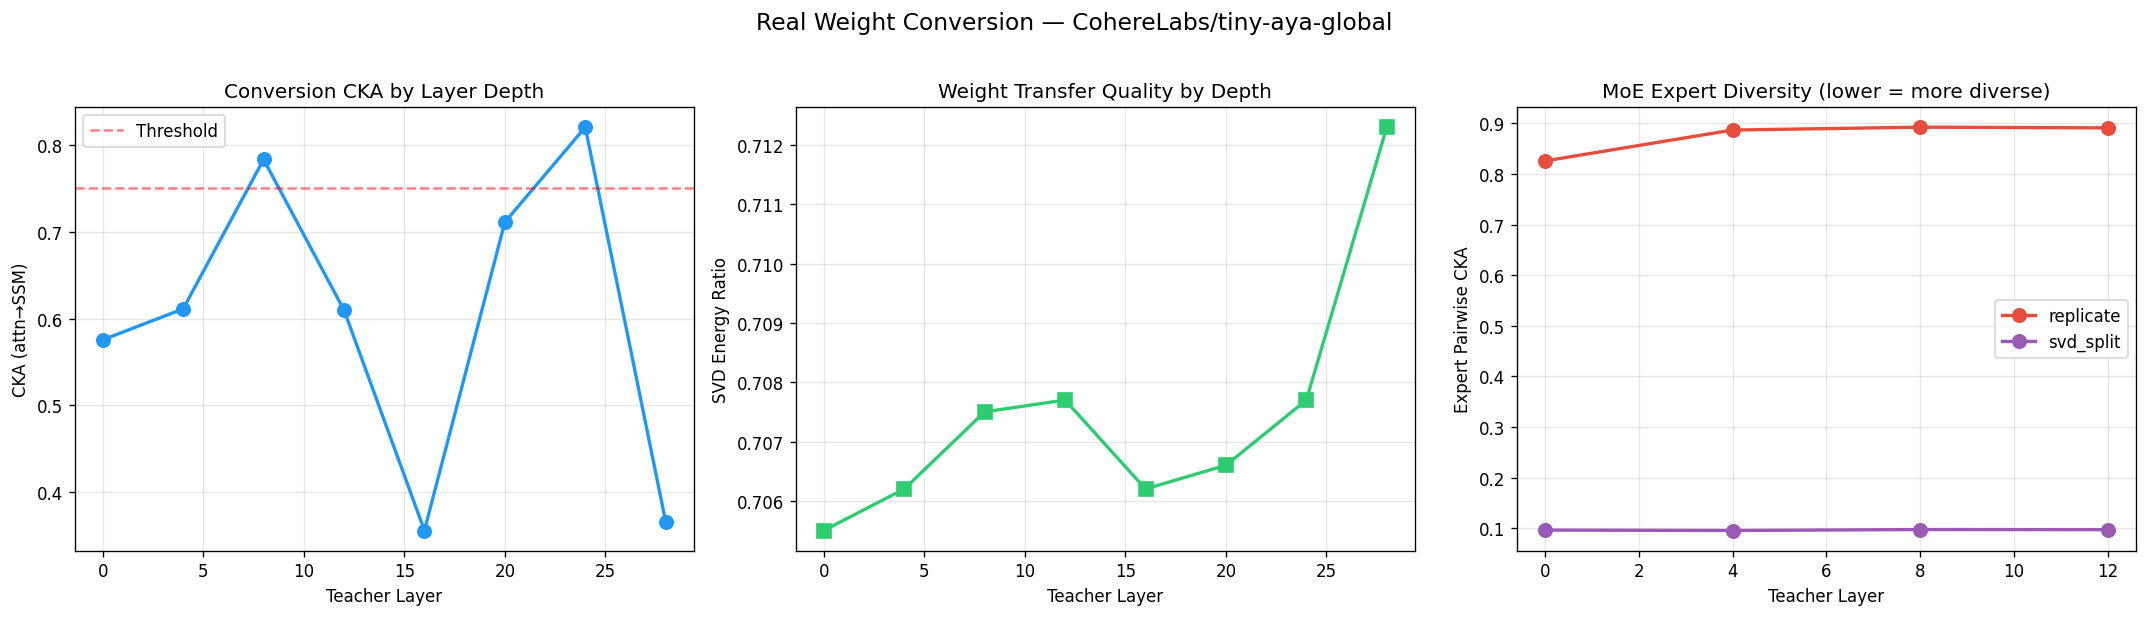

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CKA by depth
ax = axes[0]
xs = [r["teacher_layer"] for r in conversion_results]
ys = [r["cka"] for r in conversion_results]
ax.plot(xs, ys, "o-", linewidth=2, markersize=8, color="#2196F3")
ax.axhline(y=0.75, color="red", linestyle="--", alpha=0.5, label="Threshold")
ax.set_xlabel("Teacher Layer")
ax.set_ylabel("CKA (attn→SSM)")
ax.set_title("Conversion CKA by Layer Depth")
ax.legend()
ax.grid(True, alpha=0.3)

# Energy ratio by depth
ax = axes[1]
es = [r["energy_ratio"] for r in conversion_results]
ax.plot(xs, es, "s-", linewidth=2, markersize=8, color="#2ecc71")
ax.set_xlabel("Teacher Layer")
ax.set_ylabel("SVD Energy Ratio")
ax.set_title("Weight Transfer Quality by Depth")
ax.grid(True, alpha=0.3)

# MoE expert diversity
ax = axes[2]
for strat, color in [("replicate", "#e74c3c"), ("svd_split", "#9b59b6")]:
    subset = [r for r in moe_results if r["strategy"] == strat]
    ax.plot([r["teacher_layer"] for r in subset],
            [r["mean_expert_cka"] for r in subset],
            "o-", label=strat, linewidth=2, markersize=8, color=color)
ax.set_xlabel("Teacher Layer")
ax.set_ylabel("Expert Pairwise CKA")
ax.set_title("MoE Expert Diversity (lower = more diverse)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f"Real Weight Conversion — {MODEL_NAME}", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../results/real_conversion_quality.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Summary

In [9]:
results = {
    "model": MODEL_NAME,
    "n_layers": n_layers,
    "hidden_size": hidden,
    "student_d_model": student_d_model,
    "layer_self_similarity": {
        "sampled_layers": sample_layers,
        "cka_matrix": cka_matrix.tolist(),
    },
    "cross_lingual": {
        "n_languages": len(langs),
        "languages": langs,
        "mean_similarity": round(float(np.mean(sim_matrix[np.triu_indices_from(sim_matrix, k=1)])), 4),
    },
    "attn_to_ssm_conversion": {
        "mean_cka": round(mean_cka, 4),
        "per_layer": conversion_results,
    },
    "ffn_to_moe_conversion": moe_results,
}

with open("../results/07_teacher_representations.json", "w") as f:
    json.dump(results, f, indent=2, default=str)

print("KEY FINDINGS")
print("=" * 60)
print(f"1. Teacher has {n_layers} layers, hidden={hidden}")
print(f"2. Mean layer self-CKA: {np.mean(cka_matrix[np.triu_indices_from(cka_matrix, k=1)]):.4f}")
print(f"3. Mean cross-lingual similarity: {results['cross_lingual']['mean_similarity']}")
print(f"4. Real attn→SSM conversion CKA: {mean_cka:.4f} (threshold: 0.75)")
print(f"5. SVD split produces more diverse experts than replicate")
print(f"\nResults saved to results/07_teacher_representations.json")

KEY FINDINGS
1. Teacher has 36 layers, hidden=2048
2. Mean layer self-CKA: 0.5749
3. Mean cross-lingual similarity: 0.8787
4. Real attn→SSM conversion CKA: 0.6042 (threshold: 0.75)
5. SVD split produces more diverse experts than replicate

Results saved to results/07_teacher_representations.json
